# Practice Using Breast Cancer Data

The load_breast_cancer command provides breast cancer diagnosis data. It uses features measured from tumor images to determine whether a tumor is `benign` or `malignant`.

In [347]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [348]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

## Pairplot
Investigate and Visualize.

Let's use four features : ["mean radius", "mean texture", "mean perimeter", "mean area"]

In [349]:
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["target"] = cancer.target
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


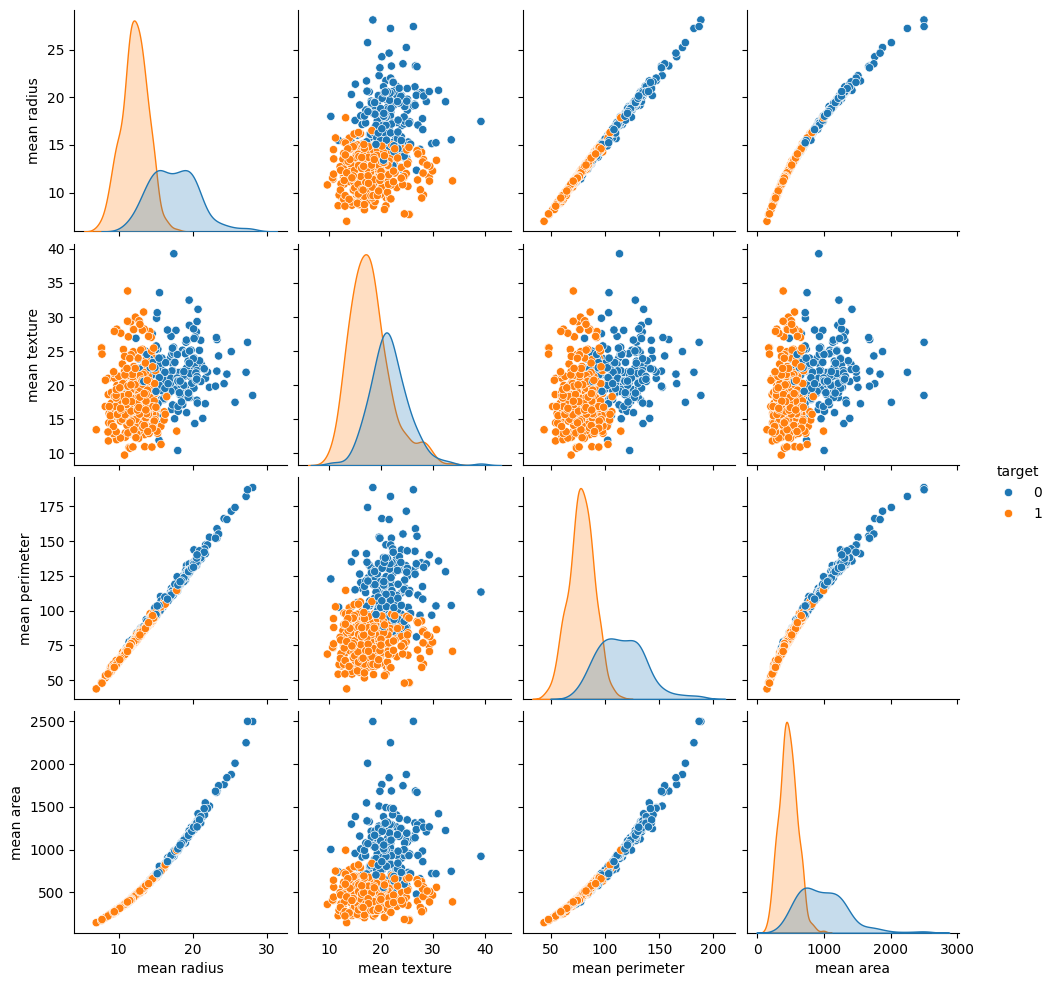

In [350]:
sns.pairplot(
    vars=["mean radius", "mean texture", "mean perimeter", "mean area"],
    hue="target",
    data=df,
)
plt.show()

## Train Test Split

In [351]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42
)

## Regularization
Prevent overfitting.

- `L1` - Keeps only important variables.
- `L2` - Default. Penalizes weights of less important variables, pushing them closer to zero.

The regularization strength parameter C is important.
- Lower C ⇒ stronger regularization; weights are pushed closer to zero, which may cause underfitting.
- Higher C ⇒ weaker regularization; the model tries to fit all data points as much as possible, which may cause overfitting.

Practice `Regularization` using:
- Change C to 999 and evaluate the model.
- Change C to 0.01 and evaluate the mode

In [352]:
from sklearn.linear_model import LogisticRegression

In [353]:
log_reg999 = LogisticRegression(solver="liblinear", C=999)
log_reg999.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,999
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [354]:
log_reg001 = LogisticRegression(solver="liblinear", C=0.01)
log_reg001.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


### Compare Accuracy

In [355]:
print("C=999")
print("Training Accuracy: {:.3f}".format(log_reg999.score(X_train, y_train)))
print("Test Accuracy: {:.3f}".format(log_reg999.score(X_test, y_test)))
print("-" * 50)
print("C=0.01")
print("Traning Accuracy: {:.3f}".format(log_reg001.score(X_train, y_train)))
print("Test Accuracy: {:.3f}".format(log_reg001.score(X_test, y_test)))

C=999
Training Accuracy: 0.977
Test Accuracy: 0.965
--------------------------------------------------
C=0.01
Traning Accuracy: 0.934
Test Accuracy: 0.930


### Compare Predict_Probability

In [356]:
prob = log_reg999.predict_proba(X_test[:10, :])
prob.round(2)

array([[0.01, 0.99],
       [1.  , 0.  ],
       [0.15, 0.85],
       [0.08, 0.92],
       [0.27, 0.73],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.  , 1.  ]])

In [357]:
prob = log_reg001.predict_proba(X_test[:10, :])
prob.round(2)

array([[0.06, 0.94],
       [1.  , 0.  ],
       [0.13, 0.87],
       [0.22, 0.78],
       [0.17, 0.83],
       [1.  , 0.  ],
       [0.47, 0.53],
       [1.  , 0.  ],
       [0.95, 0.05],
       [0.03, 0.97]])

### Conclusion
When C is large (weaker regularization), the model tries to fit the data more closely and tends to produce more extreme probability values.

When C is small (stronger regularization), the model is more conservative and produces smoother, less extreme probability distributions.

---
## Decision Boundary Plotting when using two features

In [358]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

---
### Case1: ["mean perimeter", "mean texture"]

In [370]:
X = df[["mean perimeter", "mean texture"]]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=999)

In [371]:
pipe = make_pipeline(
    StandardScaler(), LogisticRegression(solver="liblinear", C=999, random_state=1)
)
pipe.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,999


In [372]:
print("Training Accuracy: {:.3f}".format(pipe.score(X_train, y_train)))
print("Test Accuracy: {:.3f}".format(pipe.score(X_test, y_test)))

Training Accuracy: 0.897
Test Accuracy: 0.888


/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


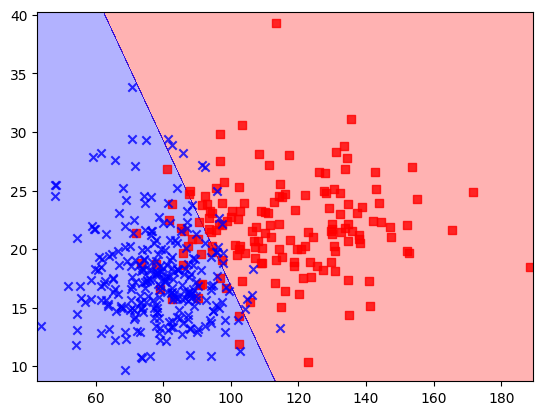

In [375]:
from mymodule.plothelper import plot_decision_regions

plot_decision_regions(X_train.values, y_train.values, pipe)

---
### Case2: ["mean perimeter", "mean radius"]

In [376]:
X = df[["mean perimeter", "mean radius"]]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=999)

In [377]:
pipe = make_pipeline(
    StandardScaler(), LogisticRegression(solver="liblinear", C=999, random_state=1)
)
pipe.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,999


In [378]:
print("Training Accuracy: {:.3f}".format(pipe.score(X_train, y_train)))
print("Test Accuracy: {:.3f}".format(pipe.score(X_test, y_test)))

Training Accuracy: 0.880
Test Accuracy: 0.951


/Users/I751244/Desktop/soop/datascience/ds101/.dsenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


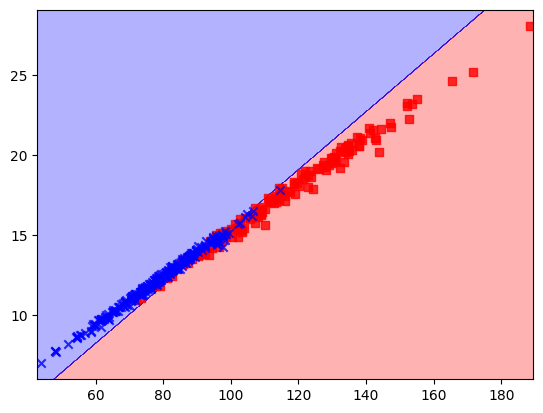

In [379]:
from mymodule.plothelper import plot_decision_regions

plot_decision_regions(X_train.values, y_train.values, pipe)